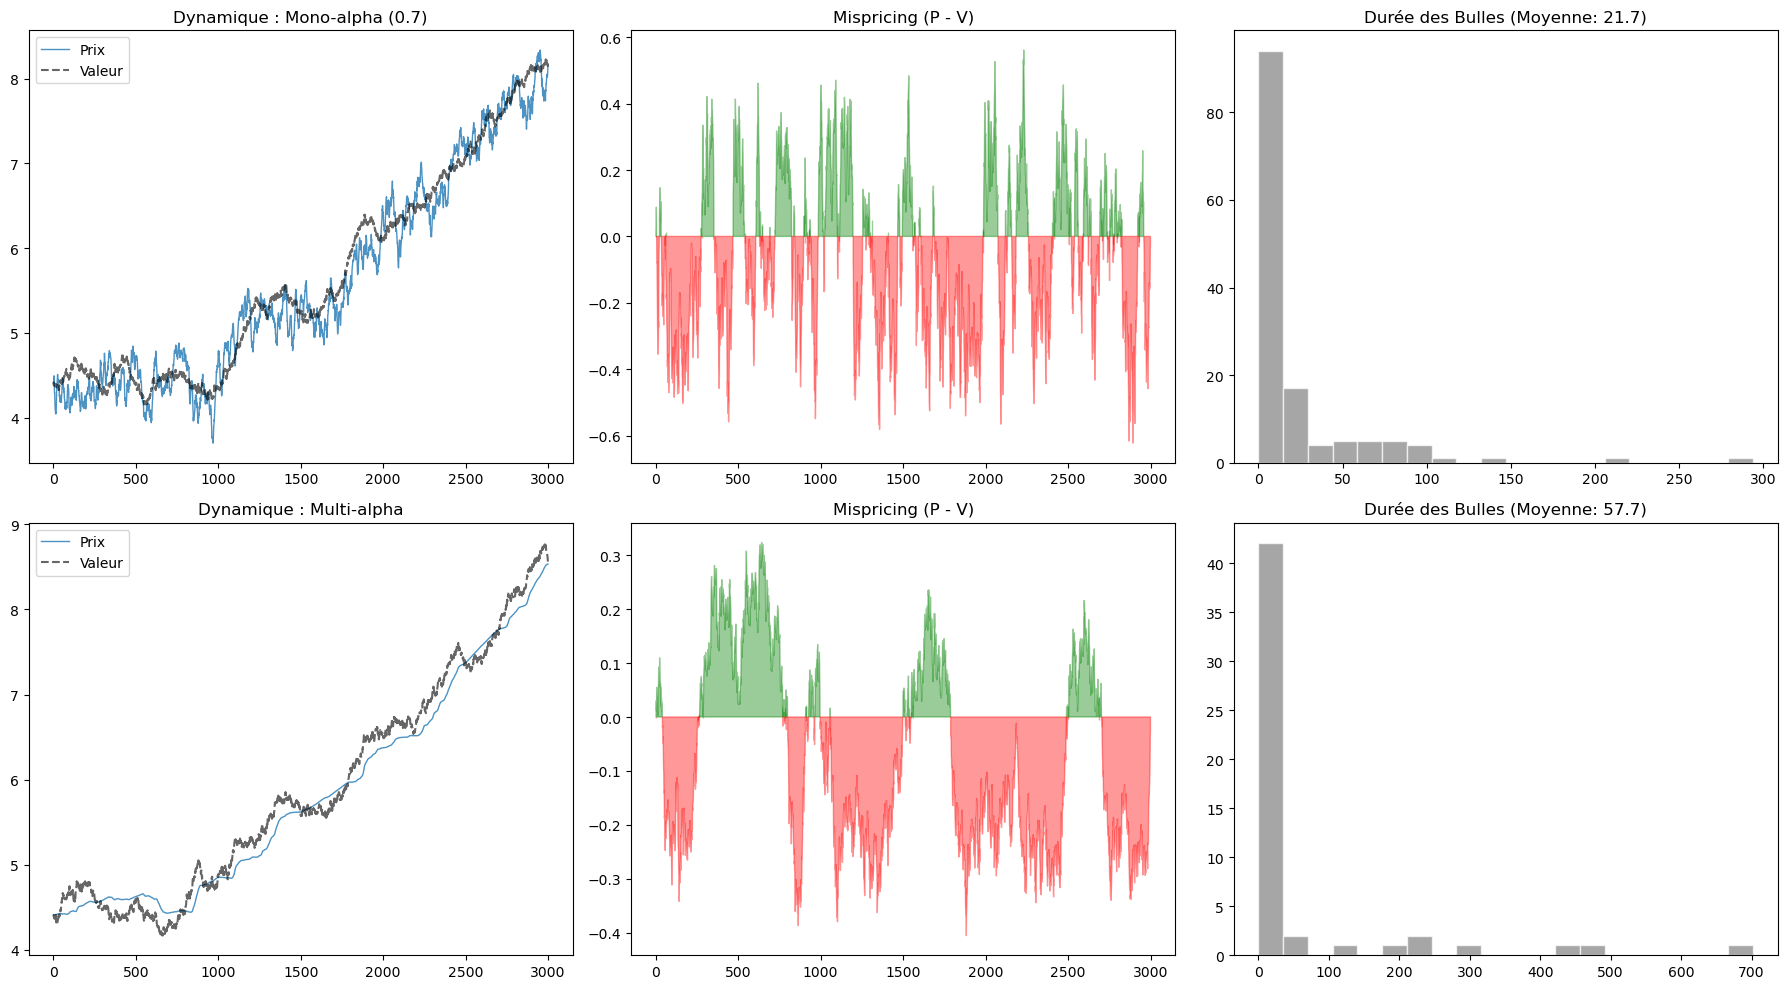

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. LE MODÈLE MULTI-ÉCHELLES (VERSION SIMPLIFIÉE) ---

def simulate_chiarella(NIT, kappa, kappa_3, beta_total, gamma, lst_alpha, 
                       sigmaN, sigmaV, P0, V0, g=0.0011, beta_dist="uniform"):
    """
    Simule le modèle de Chiarella. 
    Si len(lst_alpha) == 1, se comporte comme le modèle classique.
    """
    P = np.zeros(NIT)
    V = np.zeros(NIT)
    
    alphas = np.array(lst_alpha)
    K = len(alphas)
    # M stocke le momentum pour chaque échelle i au temps t
    M = np.zeros((K, NIT))
    
    # Gestion de la distribution des poids beta_i
    if K == 1:
        beta = np.array([beta_total])
    elif beta_dist == "uniform":
        beta = np.ones(K) * (beta_total / K)
    elif beta_dist == "exponent":
        x = np.linspace(-1, 1, K)
        beta = np.abs(x)**3
        beta = beta_total * beta / np.sum(beta)
    
    # Bruits
    epsilons = np.random.normal(0, sigmaN, NIT)
    etas = np.random.normal(0, sigmaV, NIT)
    
    # Initialisation
    P[0] = P0; P[1] = P0
    V[0] = V0; V[1] = V0 + g
    
    for t in range(1, NIT - 1):
        chartist_demand = 0
        for i in range(K):
            chartist_demand += beta[i] * np.tanh(gamma * M[i, t])
            
        # 2. Mise à jour du Prix 
        P[t+1] = P[t] + kappa * (V[t] - P[t]) + chartist_demand  + kappa_3 *((V[t] - P[t])**3) 
        if len(lst_alpha)==1 : 
            P[t+1] += epsilons[t+1]
        
        # 3. Mise à jour de la Valeur Fondamentale 
        V[t+1] = V[t] + g + etas[t+1]
        
        # 4. Mise à jour des signaux de momentum pour t+1
        for i in range(K):
            M[i, t+1] = (1 - alphas[i]) * M[i, t] + alphas[i] * (P[t] - P[t-1])
            
    return P, V

# --- 2. FONCTION D'ANALYSE DES BULLES ---

def get_bubble_stats(P, V):
    """Calcule l'écart (mispricing) et la durée des excursions hors de la valeur fondamentale"""
    delta = P - V
    # On identifie les moments où le prix croise la valeur fondamentale
    signs = np.sign(delta)
    # Suppression des zéros potentiels pour le calcul des changements de signe
    signs[signs == 0] = 1 
    crossings = np.where(np.diff(signs) != 0)[0]
    
    if len(crossings) == 0:
        return np.array([len(P)]), delta
    
    durations = np.diff(np.concatenate([[0], crossings, [len(delta)]]))
    return durations, delta

# --- 3. SIMULATIONS ---

# Paramètres fournis (calibration US)
params = dict(
    NIT=3000, 
    kappa=-0.011,kappa_3 = 0.269, 
    beta_total=0.018, gamma=36.7,
    sigmaN=0.042, sigmaV=0.018,
    P0=4.41, V0=4.41, g=0.0011
)



# Exécution
alphas_multi = np.linspace(0.001, 0.01, 10)
P_m, V_m = simulate_chiarella(**params, lst_alpha=alphas_multi, beta_dist="exponent")
P_s, V_s = simulate_chiarella(**params, lst_alpha=[0.7])

# --- 4. GRAPHIQUES COMPARATIFS ---

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (P, V, label) in enumerate([(P_s, V_s, "Mono-alpha (0.7)"), (P_m, V_m, "Multi-alpha")]):
    durations, delta = get_bubble_stats(P, V)
    
    # Col 1: Prix vs Valeur
    axes[idx, 0].plot(P, label="Prix", lw=1, alpha=0.8)
    axes[idx, 0].plot(V, label="Valeur", linestyle="--", color="black", alpha=0.6)
    axes[idx, 0].set_title(f"Dynamique : {label}")
    axes[idx, 0].legend()

    # Col 2: Écarts (Bulles)
    axes[idx, 1].fill_between(range(len(delta)), delta, 0, where=(delta > 0), color='green', alpha=0.4)
    axes[idx, 1].fill_between(range(len(delta)), delta, 0, where=(delta < 0), color='red', alpha=0.4)
    axes[idx, 1].set_title(f"Mispricing (P - V)")

    # Col 3: Distribution des durées
    axes[idx, 2].hist(durations, bins=20, color='gray', edgecolor='white', alpha=0.7)
    axes[idx, 2].set_title(f"Durée des Bulles (Moyenne: {np.mean(durations):.1f})")

plt.tight_layout()
plt.show()